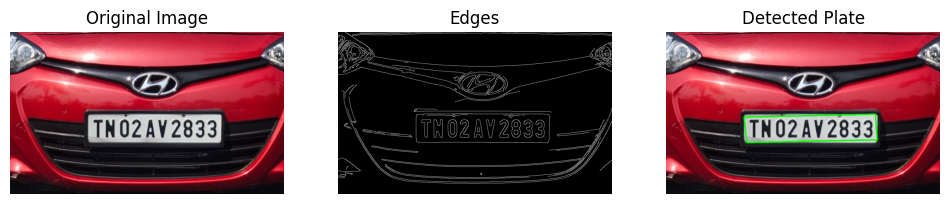

In [10]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Step 1: Load image
image = cv2.imread("car.png")   # make sure path is correct
original = image.copy()

# Step 2: Preprocessing
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# Step 3: Edge detection
edges = cv2.Canny(blur, 50, 150)

# Step 4: Find contours
contours, _ = cv2.findContours(edges.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

# Step 5: Sort contours
contours = sorted(contours, key=cv2.contourArea, reverse=True)[:10]

plate_contour = None

# Step 6: Detect rectangular contour
for contour in contours:
    approx = cv2.approxPolyDP(contour, 0.018 * cv2.arcLength(contour, True), True)
    
    if len(approx) == 4:
        plate_contour = approx
        break

# Step 7: Draw bounding box
if plate_contour is not None:
    cv2.drawContours(image, [plate_contour], -1, (0, 255, 0), 3)
else:
    print("Plate Not Detected")

# Step 8: Display using matplotlib (IMPORTANT FIX)
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(edges, cmap='gray')
plt.title("Edges")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Detected Plate")
plt.axis('off')

plt.show()

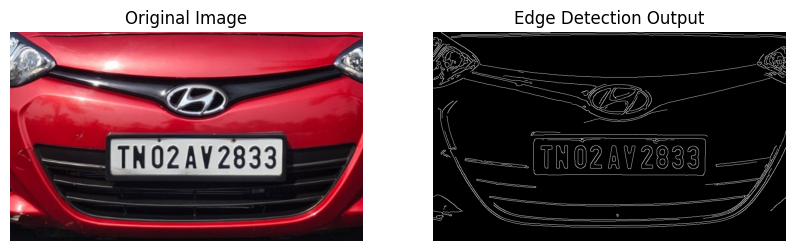

In [22]:
import cv2
from matplotlib import pyplot as plt

# Step 1: Load Image
image = cv2.imread("car.png")

# Step 2: Convert to Grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Step 3: Blur
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# Step 4: Edge Detection
edges = cv2.Canny(blur, 50, 150)

# Step 5: Display Side by Side
plt.figure(figsize=(10,5))

# Original Image
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')

# Edge Image
plt.subplot(1,2,2)
plt.imshow(edges, cmap='gray')
plt.title("Edge Detection Output")
plt.axis('off')

plt.show()